In [ ]:
### THIS CELL SETS UP THE GOOGLE COLAB ENVIRONMENT.
### IF RUNNING THIS NOTEBOOK LOCALLY, IT MAY BE SAFELY DELETED.

try:
    import google.colab
    RUNNING_IN_COLAB = True
except ImportError:
    RUNNING_IN_COLAB = False
except Exception as e:
    raise Exception("Could not figure out if running in a colab notebook\n") from e

if RUNNING_IN_COLAB:
    !pip install dataprob pymc

## Bayesian MCMC with PyMC

This notebook demonstrates the `pymc` fitter, which samples the Bayesian posterior using
PyMC's NUTS (No-U-Turn Sampler) with multiple independent chains. NUTS uses gradient
information to make efficient proposals, and multiple chains enable convergence diagnostics
(R-hat, effective sample size) via `arviz`.

**When to use:** You want gradient-based NUTS sampling with multiple chains and standard
convergence diagnostics, and are comfortable with the PyMC/PyTensor dependency.

**Note:** PyMC requires **finite bounds** for all parameters using uniform priors. An error
is raised at setup time if a parameter has `-inf` or `inf` bounds without a Gaussian prior.

### Define model

We use a linear model $y = mx + b$. The same model and data are used across all fitter
notebooks so the outputs can be directly compared.

In [1]:
%matplotlib inline
import dataprob
import numpy as np

def linear_model(m=1, b=1, x=None):
    return m*x + b

### Generate noisy data

30 observations with m = 3, b = 1, and Gaussian noise (σ = 0.5).

In [2]:
true_params = {"m": 3.0, "b": 1.0}

x = np.linspace(0, 10, 30)
y_std = 0.5
y_obs = linear_model(x=x, **true_params) + np.random.normal(0, y_std, size=x.shape)

### Configure priors

PyMC requires finite bounds on all parameters. Bounds alone give a uniform prior;
setting `prior_mean` and `prior_std` gives a truncated Gaussian prior within the bounds.
An error is raised at fit time if any parameter has infinite bounds without a Gaussian prior.

In [3]:
f = dataprob.setup(linear_model,
                   method="pymc",
                   non_fit_kwargs={"x": x})

# PyMC requires finite bounds — uniform prior within bounds
f.param_df.loc["m", "lower_bound"] = -10.0
f.param_df.loc["m", "upper_bound"] =  10.0
f.param_df.loc["b", "lower_bound"] = -10.0
f.param_df.loc["b", "upper_bound"] =  10.0

f.param_df.loc["m", "guess"] = 1.0
f.param_df.loc["b", "guess"] = 1.0

f.param_df

,name,guess,fixed,lower_bound,upper_bound,prior_mean,prior_std
name,,,,,,,
m,m,1.0,False,-10.0,10.0,NaN,NaN
b,b,1.0,False,-10.0,10.0,NaN,NaN


### Run the sampler

`draws` is the number of posterior samples per chain; `tune` is the warm-up phase used
to adapt the step size. Running multiple `chains` enables R-hat and ESS diagnostics.
Any additional keyword arguments are forwarded to `pm.sample()`.

In [14]:
f.fit(y_obs=y_obs,
      y_std=y_std,
      draws=100000,
      tune=100,
      chains=4,
      target_accept=0.65,
      output_dir=None)

Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
INFO:pymc.sampling.mcmc:CompoundStep
>Slice: [m]
INFO:pymc.sampling.mcmc:>Slice: [m]
>Slice: [b]
INFO:pymc.sampling.mcmc:>Slice: [b]


Output()

Sampling 4 chains for 100 tune and 100_000 draw iterations (400 + 400_000 draws total) took 70 seconds.
INFO:pymc.sampling.mcmc:Sampling 4 chains for 100 tune and 100_000 draw iterations (400 + 400_000 draws total) took 70 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
INFO:pymc.stats.convergence:The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


### Examine fit results

`f.fit_df["estimate"]` is the mode of the posterior marginal (KDE maximum). `f.samples`
has shape `(draws × chains, n_params)`. `f._fit_result` is the raw `arviz.InferenceData`
object and provides access to R-hat, ESS, and trace plots via `arviz`.

ValueError: minimum and maximum of vector must differ


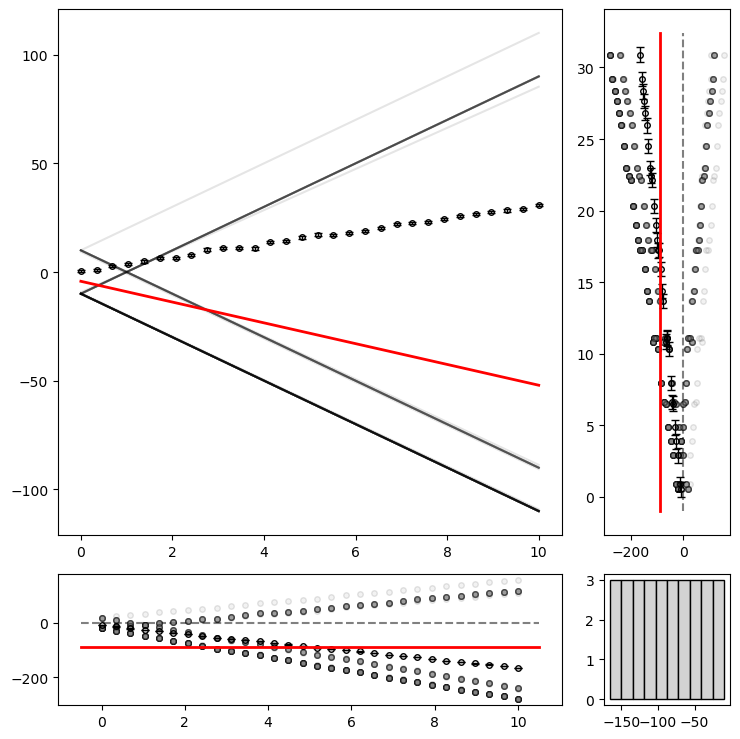

In [15]:
fig = dataprob.plot_summary(f, x_axis=x, x_label="x", y_label="y")

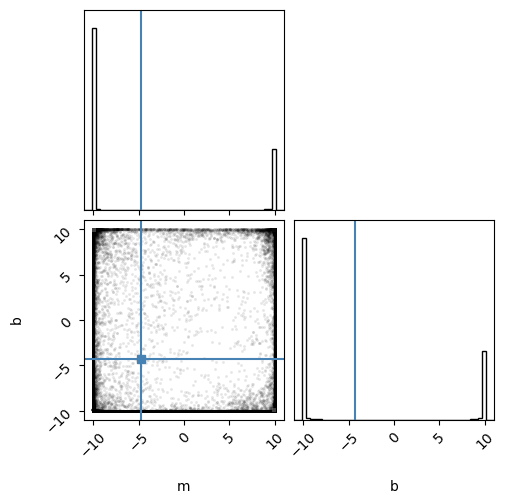

In [16]:
fig = dataprob.plot_corner(f)

In [17]:
f.fit_df

,name,estimate,std,low_95,high_95,guess,fixed,lower_bound,upper_bound,prior_mean,prior_std
name,,,,,,,,,,,
m,m,-4.78131,8.688310,-10.0,10.0,1.0,False,-10.0,10.0,NaN,NaN
b,b,-4.26285,8.886117,-10.0,10.0,1.0,False,-10.0,10.0,NaN,NaN


### Assess fit quality

`f.fit_quality` reports residual statistics. For PyMC, also check R-hat (should be ≈ 1.0)
and effective sample size (ESS) from the arviz summary via `f._fit_result`.

In [18]:
f.fit_quality

,description,is_good,value,message
name,,,,
success,fit success status,True,True,
num_obs,number of observations,True,30,
num_param,number of fit parameters,True,2,There are 28 more observations than fit parame...
lnL,log likelihood,True,-148349.750472,
chi2,chi^2 goodness-of-fit,False,0.0,A p-value of 0.000e+00 for the a goodness-of-f...
reduced_chi2,reduced chi^2,False,10988.368647,A reduced chi^2 value of 10988.369 may mean th...
mean0_resid,t-test for residual mean != 0,False,0.0,A p-value of 4.168e-11 for the one-sample t-te...
durbin-watson,Durbin-Watson test for correlated residuals,False,0.003042,A Durbin-Watson test-statistic of 0.003 is is ...
ljung-box,Ljung-Box test for correlated residuals,False,0.0,A p-value of 0.000e+00 for the Ljung-Box test ...


In [19]:
# Optional: full arviz diagnostics including R-hat and ESS per parameter
try:
    import arviz as az
    print(az.summary(f._fit_result))
except ImportError:
    print("arviz not installed — install with: pip install arviz")

    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
m -4.781  8.688   -10.0     10.0      3.265    1.772       6.0       9.0   
b -4.263  8.886   -10.0     10.0      3.339    1.576       5.0       6.0   

   r_hat  
m   1.77  
b   2.29  
